In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv('Daily activity metrics.csv')

In [9]:
df.head()

,Date,Move Minutes count,Calories (kcal),Distance (m),Heart Points,Heart Minutes,Low latitude (deg),Low longitude (deg),High latitude (deg),High longitude (deg),...,Max weight (kg),Min weight (kg),Biking duration (ms),Inactive duration (ms),Walking duration (ms),Running duration (ms),Dancing duration (ms),P90x duration (ms),Yoga duration (ms),Other duration (ms)
0,2023-10-15,2.0,779.678985,115.486305,NaN,NaN,NaN,NaN,NaN,NaN,...,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-10-16,97.0,1716.095232,3504.223000,5.0,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2695964.0,NaN,NaN,NaN,NaN,NaN
2,2023-10-17,4.0,1608.673581,237.497259,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,769698.0,NaN,NaN,NaN,NaN,NaN
3,2023-10-18,59.0,1725.420753,1268.637838,35.0,35.0,NaN,NaN,NaN,NaN,...,NaN,NaN,1983437.0,NaN,740402.0,NaN,NaN,NaN,NaN,NaN
4,2023-10-19,62.0,1758.085608,2352.492572,35.0,35.0,NaN,NaN,NaN,NaN,...,NaN,NaN,1515235.0,NaN,1828029.0,NaN,NaN,NaN,NaN,NaN


In [10]:
df.describe()

,Move Minutes count,Calories (kcal),Distance (m),Heart Points,Heart Minutes,Low latitude (deg),Low longitude (deg),High latitude (deg),High longitude (deg),Average speed (m/s),...,Max weight (kg),Min weight (kg),Biking duration (ms),Inactive duration (ms),Walking duration (ms),Running duration (ms),Dancing duration (ms),P90x duration (ms),Yoga duration (ms),Other duration (ms)
count,524.000000,533.000000,532.000000,465.000000,465.000000,22.000000,22.000000,22.000000,22.000000,532.000000,...,2.000000,2.000000,3.170000e+02,4.000000,5.160000e+02,39.000000,1.0,3.000000e+00,1.0,1.500000e+01
mean,92.154580,1821.027473,3771.289872,40.492473,39.913978,31.248419,75.696065,31.259621,75.708229,0.528292,...,67.910000,67.910000,1.881197e+06,8365.000000,3.505528e+06,151848.000000,900000.0,2.400000e+06,4417.0,1.113952e+06
std,58.557655,180.493787,2794.564501,25.866877,25.355684,0.006145,0.003236,0.004849,0.013597,0.122230,...,2.955707,2.955707,1.088523e+06,7261.363738,2.502950e+06,115447.315561,NaN,1.307670e+06,NaN,7.762059e+05
min,1.000000,779.678985,15.006695,1.000000,1.000000,31.221579,75.684181,31.251568,75.694824,0.250112,...,65.820000,65.820000,1.957680e+05,1154.000000,3.380600e+04,33803.000000,900000.0,1.500000e+06,4417.0,4.346800e+04
25%,54.000000,1695.723328,1662.239349,22.000000,22.000000,31.249043,75.694777,31.256077,75.705521,0.443387,...,66.865000,66.865000,1.063999e+06,3980.750000,1.751324e+06,84320.500000,900000.0,1.650000e+06,4417.0,3.934580e+05
50%,88.000000,1810.341828,3455.315622,40.000000,39.000000,31.249099,75.696964,31.260180,75.706749,0.516708,...,67.910000,67.910000,1.716992e+06,7139.500000,3.084955e+06,101582.000000,900000.0,1.800000e+06,4417.0,1.166552e+06
75%,130.250000,1926.759199,5121.834438,54.000000,54.000000,31.249335,75.697601,31.261868,75.707567,0.602355,...,68.955000,68.955000,2.367310e+06,11523.750000,4.686197e+06,174513.500000,900000.0,2.850000e+06,4417.0,1.509798e+06
max,365.000000,2474.343002,16674.695757,149.000000,139.000000,31.253826,75.701752,31.274950,75.766800,0.996177,...,70.000000,70.000000,7.284445e+06,18027.000000,1.496598e+07,600000.000000,900000.0,3.900000e+06,4417.0,2.522502e+06


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533 entries, 0 to 532
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    533 non-null    object 
 1   Move Minutes count      524 non-null    float64
 2   Calories (kcal)         533 non-null    float64
 3   Distance (m)            532 non-null    float64
 4   Heart Points            465 non-null    float64
 5   Heart Minutes           465 non-null    float64
 6   Low latitude (deg)      22 non-null     float64
 7   Low longitude (deg)     22 non-null     float64
 8   High latitude (deg)     22 non-null     float64
 9   High longitude (deg)    22 non-null     float64
 10  Average speed (m/s)     532 non-null    float64
 11  Max speed (m/s)         532 non-null    float64
 12  Min speed (m/s)         532 non-null    float64
 13  Step count              533 non-null    int64  
 14  Average weight (kg)     2 non-null      fl

## 1.cleanig and processing of data

In [34]:
# Rename columns for easier handling of data
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[()]', '', regex=True)

# Convert 'date' to datetime to access them easily while analysis
df['date'] = pd.to_datetime(df['date'])

# Add time features as per this data is based on date and time
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.day_name()

# Drop very sparse columns (less than 5% non-null) for better analyse of datasets
threshold = len(df) * 0.05
df = df.dropna(thresh=threshold, axis=1)

# Optionally fill or interpolate missing values for key columns
df['move_minutes_count'] = df['move_minutes_count'].interpolate()
df['heart_points'] = df['heart_points'].fillna(0)
df['walking_duration_ms'] = df['walking_duration_ms'].fillna(0)


## 2.Daily Activity overview

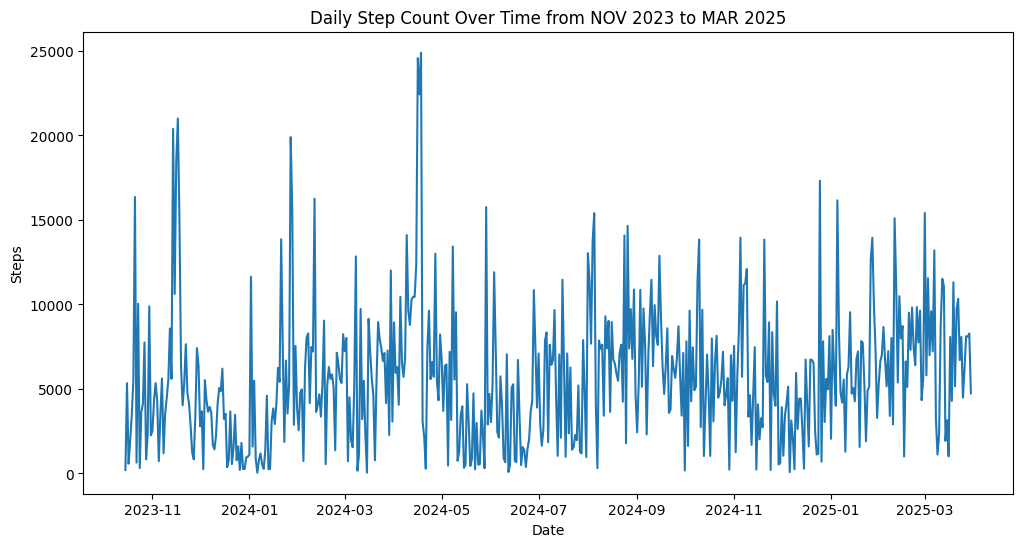

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='step_count', data=df)
plt.title('Daily Step Count Over Time from NOV 2023 to MAR 2025')
plt.ylabel('Steps')
plt.xlabel('Date')
plt.show()


## 3.weekly summary


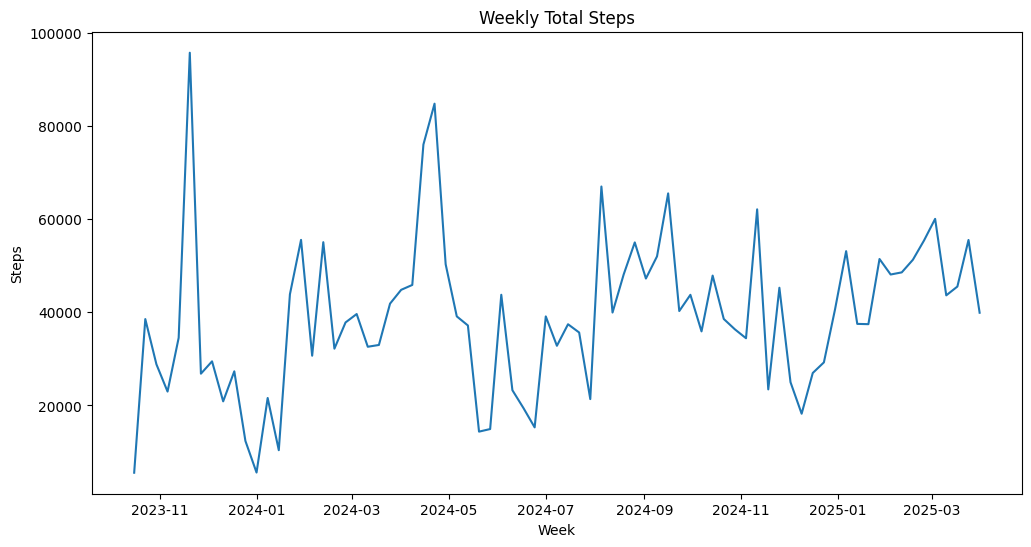

In [40]:
weekly_df = df.resample('W-Mon', on='date').sum(numeric_only=True).reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=weekly_df, x='date', y='step_count')
plt.title('Weekly Total Steps')
plt.xlabel('Week')
plt.ylabel('Steps')
plt.show()


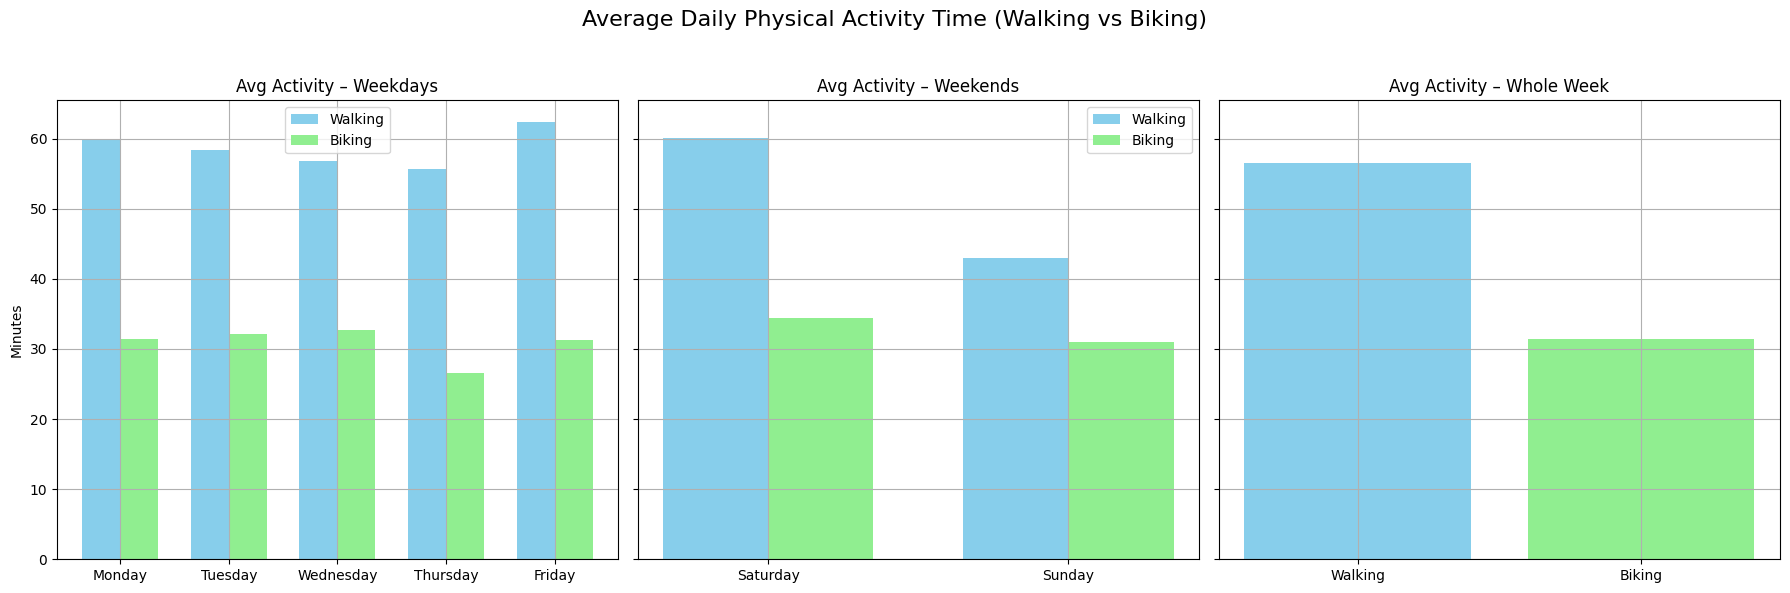

In [41]:
# Converting  durations from ms to minutes for esay understanding
df['walking_minutes'] = df['walking_duration_ms'] / (1000 * 60)
df['biking_minutes'] = df['biking_duration_ms'] / (1000 * 60)

# Defining days for charts 
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
weekends = ['Saturday', 'Sunday']

#  Group by weekday
weekday_avg = df[df['day_of_week'].isin(weekdays)].groupby('day_of_week')[['walking_minutes', 'biking_minutes']].mean()
weekday_avg = weekday_avg.reindex(weekdays)  # Ensure correct order

#  Group by weekend
weekend_avg = df[df['day_of_week'].isin(weekends)].groupby('day_of_week')[['walking_minutes', 'biking_minutes']].mean()
weekend_avg = weekend_avg.reindex(weekends)  # Ensure correct order

#  Whole week average
weekly_avg = df[['walking_minutes', 'biking_minutes']].mean()

#  Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

bar_width = 0.35
x_weekdays = np.arange(len(weekday_avg))
x_weekends = np.arange(len(weekend_avg))

##  Weekdays subplot
axs[0].bar(x_weekdays - bar_width/2, weekday_avg['walking_minutes'], bar_width, label='Walking', color='skyblue')
axs[0].bar(x_weekdays + bar_width/2, weekday_avg['biking_minutes'], bar_width, label='Biking', color='lightgreen')
axs[0].set_title('Avg Activity – Weekdays')
axs[0].set_xticks(x_weekdays)
axs[0].set_xticklabels(weekday_avg.index)
axs[0].set_ylabel('Minutes')
axs[0].legend()
axs[0].grid(True)

##  Weekends subplot
axs[1].bar(x_weekends - bar_width/2, weekend_avg['walking_minutes'], bar_width, label='Walking', color='skyblue')
axs[1].bar(x_weekends + bar_width/2, weekend_avg['biking_minutes'], bar_width, label='Biking', color='lightgreen')
axs[1].set_title('Avg Activity – Weekends')
axs[1].set_xticks(x_weekends)
axs[1].set_xticklabels(weekend_avg.index)
axs[1].legend()
axs[1].grid(True)

##  Whole week subplot
axs[2].bar(['Walking', 'Biking'], weekly_avg.values, color=['skyblue', 'lightgreen'])
axs[2].set_title('Avg Activity – Whole Week')
axs[2].grid(True)

# 🔝 Overall title
plt.suptitle('Average Daily Physical Activity Time (Walking vs Biking)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 5. Monthly and Yearly Analysis

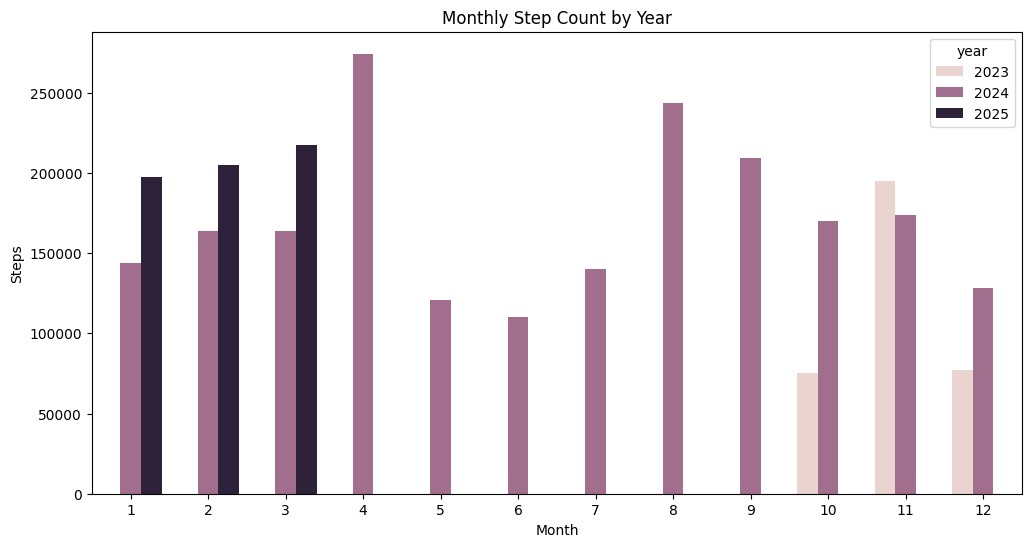

In [19]:
monthly_df = df.groupby(['year', 'month'])[['step_count', 'calories_kcal']].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='step_count', hue='year', data=monthly_df)
plt.title('Monthly Step Count by Year')
plt.xlabel('Month')
plt.ylabel('Steps')
plt.show()


## 6. Activity Type Breakdown

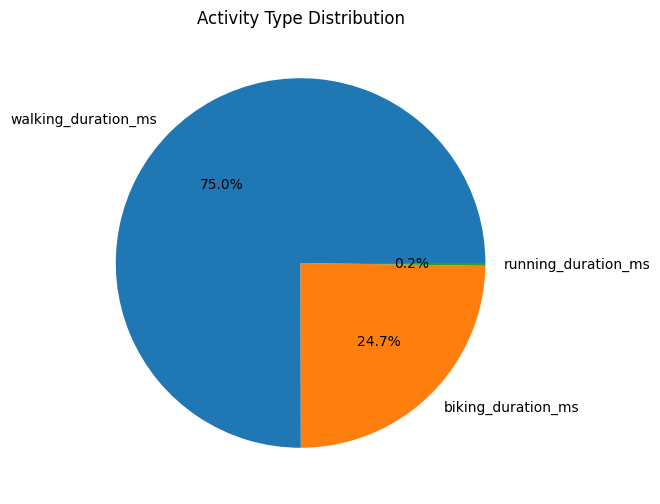

In [21]:
activity_columns = ['walking_duration_ms', 'biking_duration_ms', 'running_duration_ms']
activity_summary = df[activity_columns].sum()

plt.figure(figsize=(8, 6))
activity_summary.plot(kind='pie', autopct='%1.1f%%')
plt.title('Activity Type Distribution')
plt.ylabel('')
plt.show()


##  activity analysis of 2024

/tmp/ipykernel_7009/3314925737.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='distance_km', data=monthly,palette="viridis")


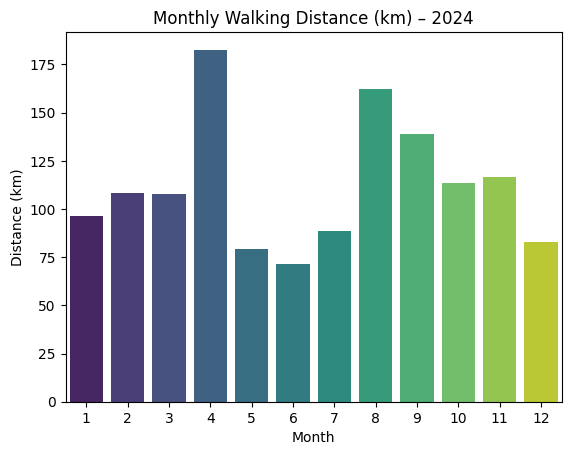

In [45]:
# Monthly walking distance
monthly = df[df['year'] == 2024].groupby('month')['distance_m'].sum().reset_index()
monthly['distance_km'] = monthly['distance_m'] / 1000
#sns.lineplot(x='month', y='distance_km', data=monthly,marker="D")
sns.barplot(x='month', y='distance_km', data=monthly,palette="viridis")
plt.title('Monthly Walking Distance (km) – 2024')
plt.xlabel('Month')
plt.ylabel('Distance (km)')
plt.show()


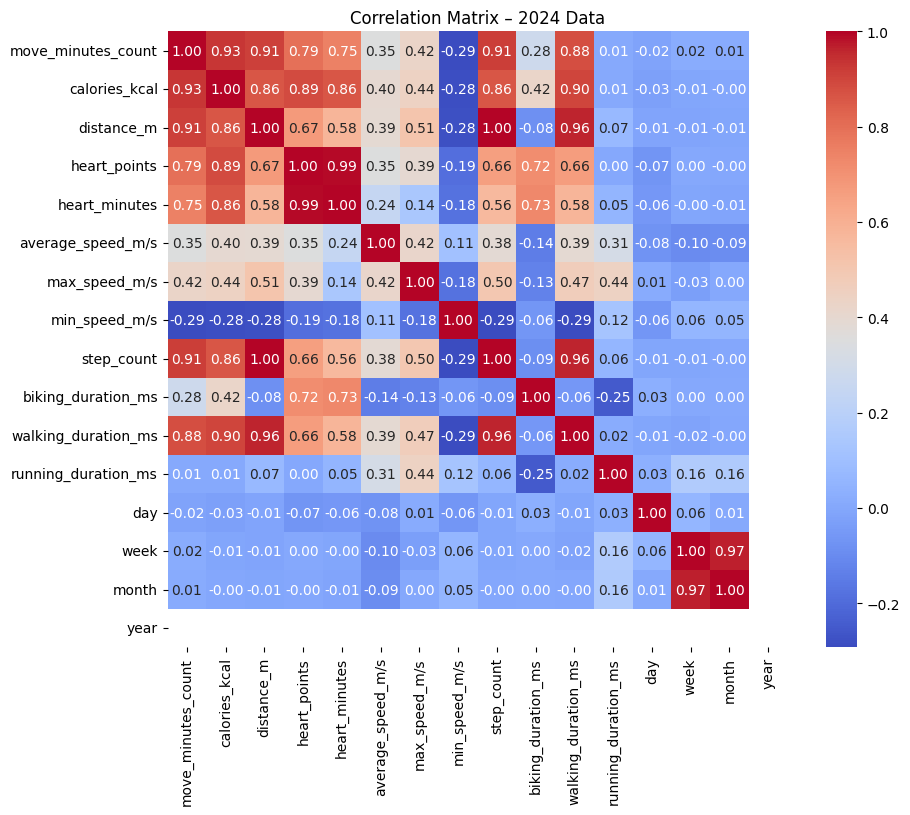

In [25]:
# Correlation matrix for numeric columns
corr_data = df[df['year'] == 2024].select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix – 2024 Data')
plt.show()


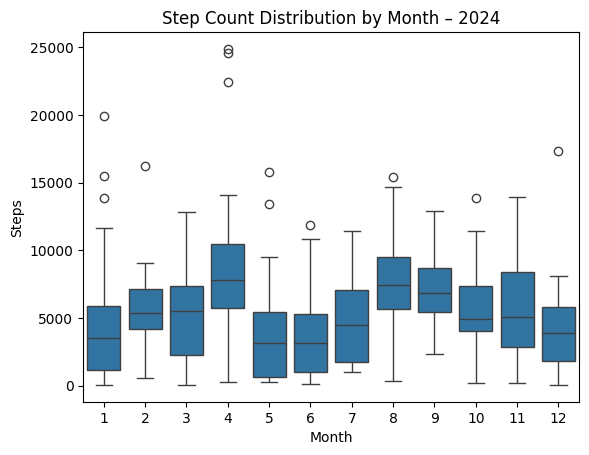

In [26]:
# Steps per month
sns.boxplot(x='month', y='step_count', data=df[df['year'] == 2024])
plt.title('Step Count Distribution by Month – 2024')
plt.xlabel('Month')
plt.ylabel('Steps')
plt.show()


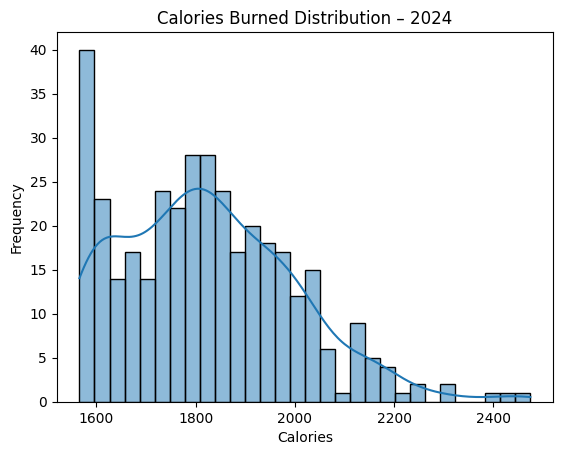

In [27]:
# Distribution of calories burned
df_2024 = df[df['year'] == 2024]
sns.histplot(df_2024['calories_kcal'], bins=30, kde=True)
plt.title('Calories Burned Distribution – 2024')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()


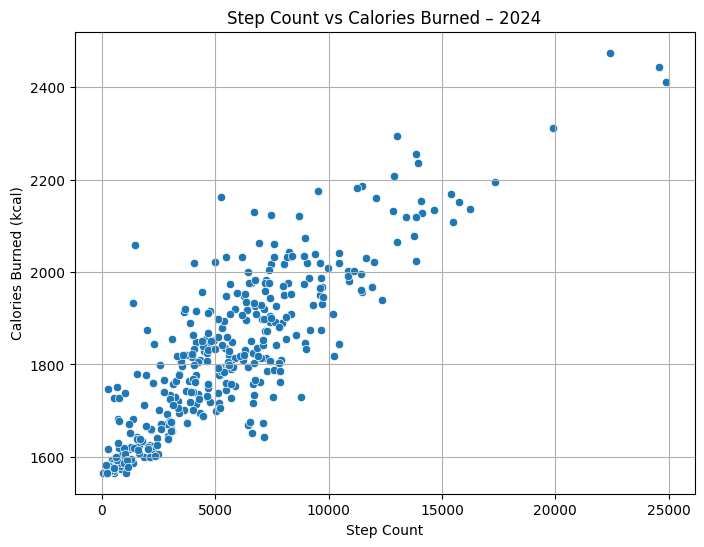

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for 2024
df_2024 = df[df['year'] == 2024]

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_2024, x='step_count', y='calories_kcal')

plt.title('Step Count vs Calories Burned – 2024')
plt.xlabel('Step Count')
plt.ylabel('Calories Burned (kcal)')
plt.grid(True)
plt.show()


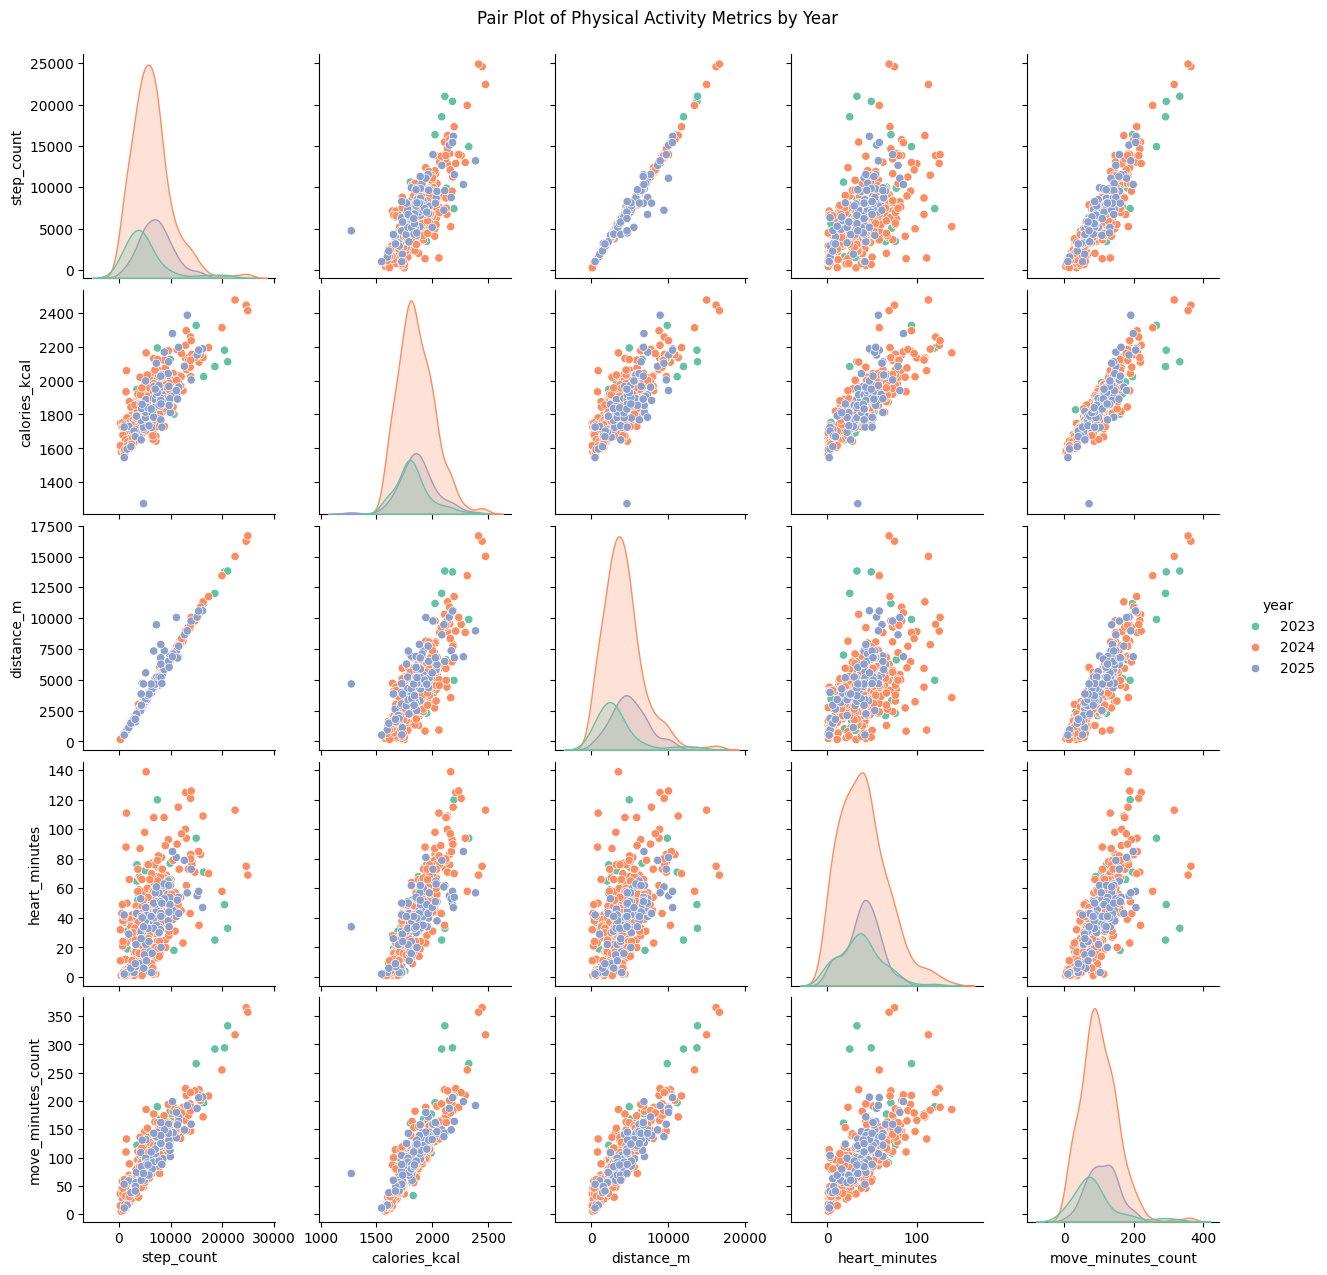

In [31]:
# Filter out rows with missing key data
selected_columns = ['step_count', 'calories_kcal', 'distance_m', 'heart_minutes', 'move_minutes_count', 'year']
pairplot_data = df[selected_columns].dropna()

# Create pair plot
sns.pairplot(pairplot_data, hue='year', palette='Set2')
plt.suptitle('Pair Plot of Physical Activity Metrics by Year', y=1.02)
plt.show()